# Lab 1 — Partner A: weather

**Tonight you don't clean data. You run, you plot, you ship.** The cleaning was done for you
(there's a short "how it was cleaned" note below so you're not flying blind). Your job:

1. Run the setup + the **line plot** (already written — it saves `weather_line.png`)
2. **Write one histogram** yourself (your only coding task) — it saves `weather_hist.png`
3. Get the notebook and both PNGs into your repo on branch **`dev-weather`**, and open a pull request

🚫 No AI tonight. The histogram is three lines; type them.


Test

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# CHANGE THIS to your campus: "hartford" (KBDL) or "stamford" (KBDR)
CAMPUS = "hartford"

# The cleaned weather file. Same file sits in YOUR repo at data/clean/ — this reads the class copy so
# there's nothing to configure tonight.
url = f"https://raw.githubusercontent.com/drdave-teaching/opim5512-lab1-template/main/data/clean/weather_hourly_{CAMPUS}.csv"
wx = pd.read_csv(url, parse_dates=["hour"])

print(CAMPUS, "|", len(wx), "hours |", wx["hour"].min(), "->", wx["hour"].max())
wx.head()

hartford | 743 hours | 2026-07-20 00:00:00 -> 2026-08-19 23:00:00


,hour,temp_f,dewpoint_f,humidity_pct,wind_kt
0,2026-07-20 00:00:00,65.0,51.0,60.49,5.0
1,2026-07-20 01:00:00,60.0,51.0,72.13,4.0
2,2026-07-20 02:00:00,60.0,51.0,72.13,0.0
3,2026-07-20 03:00:00,55.0,51.0,86.35,0.0
4,2026-07-20 04:00:00,57.0,53.0,86.46,4.0


### How this was cleaned (read it — don't code it tonight)

The raw file was airport **METAR** reports: missing values were the letter **`M`**, trace rain was **`T`**,
and readings landed at **:51 past the hour**. The cleaning (a) read `M` as missing, (b) floored each
timestamp to the hour, and (c) averaged the rare hours that had two reports. Result: one row per hour.

| column | meaning | units |
|---|---|---|
| `hour` | the hour that **begins** at this timestamp | — |
| `temp_f` | air temperature | °F |
| `dewpoint_f` | dew point | °F |
| `humidity_pct` | relative humidity | % |
| `wind_kt` | wind speed | knots |

*(Want the full version where you do the cleaning yourself? It's the "extended" Lab 1 in the class repo.)*


## 1. The line plot (already written — just run it)

Temperature across the month. **Plot against time, not row number** — the question is *when*.

saved weather_line.png


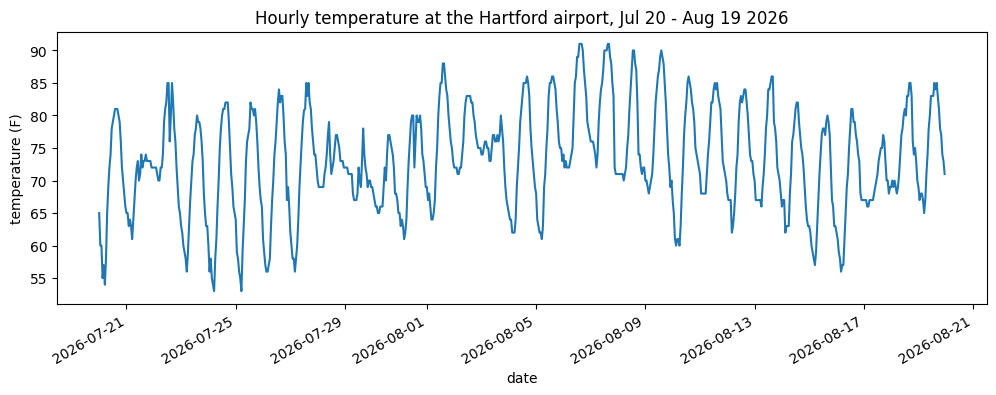

In [17]:
ax = wx.plot(x="hour", y="temp_f", figsize=(12, 4), legend=False,
             title=f"Hourly temperature at the {CAMPUS.title()} airport, Jul 20 - Aug 19 2026")
ax.set_xlabel("date"); ax.set_ylabel("temperature (F)")
ax.get_figure().savefig("weather_line.png", dpi=150, bbox_inches="tight")
print("saved weather_line.png")

## 2. Your turn: one histogram

Same data, different question: **how often is it hot?** A histogram of `temp_f` answers that.

Write it below. The shape is:

```
ax = wx["temp_f"].plot.hist(bins=20, figsize=(8, 4), title="...")
ax.set_xlabel("...")
ax.get_figure().savefig("weather_hist.png", dpi=150, bbox_inches="tight")
```

Give it a title that says what a reader should notice, and label the x-axis with units.
Look at it: where's the bulk of the hours? How many hours are above 85 °F?

### Download both PNGs to your laptop

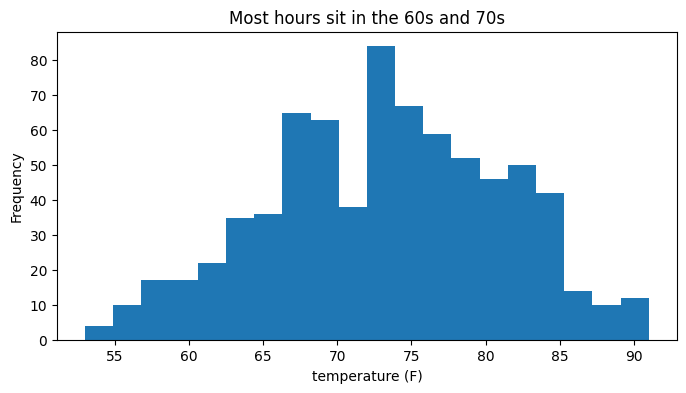

In [18]:
ax = wx["temp_f"].plot.hist(bins=20, figsize=(8, 4), title="Most hours sit in the 60s and 70s")
ax.set_xlabel("temperature (F)")
ax.get_figure().savefig("weather_hist.png", dpi=150, bbox_inches="tight")

In [19]:
import os
from google.colab import files
for p in ["weather_line.png", "weather_hist.png"]:
    if os.path.exists(p):
        files.download(p)
    else:
        print(f"{p} not found yet - run the cell that makes it (your histogram cell above), then re-run this one.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Ship it (this is the real lab)

Two things leave Colab. They travel differently — that's on purpose.

1. **This notebook → GitHub:** **File → Save** (Colab commits it straight to your repo).
   In the dialog: **your** repo · branch **`dev-weather`** · keep the path **`notebooks/Lab1_A_Weather.ipynb`** · write a real commit message.
   (No "Save a copy in GitHub" item exists — plain **Save** is the one. Ctrl+S only autosaves to Drive.)
2. **The two PNGs → your laptop → the repo:** the cell above downloaded them. In **GitHub Desktop → Repository → Show in Explorer**, drag both into the **`images/`** folder.
   ⚠️ If a filename has **`(1)`** in it, rename it back before you drag — the report links to the *exact* names.

Then in GitHub Desktop: confirm the top bar says **`dev-weather`** → **Commit** (real message) → **Push** → on github.com **Compare & pull request** → ask your partner to review.
